In [158]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt

## Read the data 

In [159]:
df = pd.read_csv("../dataset/motorcycles_clean.csv")

In [160]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              361 non-null    str    
 1   Country of Origin    361 non-null    str    
 2   Model                361 non-null    str    
 3   Number of cc         360 non-null    float64
 4   Horsepower           361 non-null    float64
 5   Torque               360 non-null    float64
 6   Transmission Type    361 non-null    str    
 7   Drivetrain           361 non-null    str    
 8   Number of Seating    361 non-null    int64  
 9   Year                 361 non-null    int64  
 10  Looks                361 non-null    str    
 11  Body Type            361 non-null    str    
 12  Engine Type          361 non-null    str    
 13  Number of Cylinders  359 non-null    float64
 14  Price (SEK)          361 non-null    float64
dtypes: float64(5), int64(2), str(8)
memory usage: 64.0 

In [161]:
df.dropna(inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 357 entries, 0 to 360
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              357 non-null    str    
 1   Country of Origin    357 non-null    str    
 2   Model                357 non-null    str    
 3   Number of cc         357 non-null    float64
 4   Horsepower           357 non-null    float64
 5   Torque               357 non-null    float64
 6   Transmission Type    357 non-null    str    
 7   Drivetrain           357 non-null    str    
 8   Number of Seating    357 non-null    int64  
 9   Year                 357 non-null    int64  
 10  Looks                357 non-null    str    
 11  Body Type            357 non-null    str    
 12  Engine Type          357 non-null    str    
 13  Number of Cylinders  357 non-null    float64
 14  Price (SEK)          357 non-null    float64
dtypes: float64(5), int64(2), str(8)
memory usage: 66.3 KB


## Spliting the data

In [162]:
categorical_features = [
    "Company",
    "Body Type",
    "Looks",
    "Country of Origin",
    "Transmission Type",
    "Drivetrain"
]

numeric_features = [
    "Number of cc",
    "Horsepower",
    "Torque",
    "Year",
    "Number of Cylinders",
    "Number of Seating",
]

x = df[categorical_features + numeric_features]
y = df["Price (SEK)"]

## Train, Val, Test

In [163]:
x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.2, random_state=42)

In [164]:
# Convert categorical features to numerical values and keep numerical features unchanged.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

## Linear regression
initialising train and prediction

In [165]:
lin_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())])
lin_reg.fit(x_train, y_train)
lin_reg_pred = lin_reg.predict(x_val)

In [166]:
def regression_metrics(y_true, y_pred):
    return {
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

result = regression_metrics(y_val, lin_reg_pred)
print(result)

{'RMSE': 21820.658521794474, 'MSE': 476141138.32476175, 'MAE': 14345.697790386981}


## First evaluation for linear regression and it preformed not as well as i would hope.

===================================================================================================================================================================

## Trying forest with hyper params

In [167]:
tree_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))])
hyperparameters = {
    "model__n_estimators": [210, 220, 230],
    "model__max_depth": [None, 5, 10, 12],
    "model__min_samples_split": [2, 3],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", 0.5, 0.8]
}

# Best Hyperparams
# n_estimators=220,
# max_depth=None,
# min_samples_split=3,
# min_samples_leaf=1,
# max_features=0.5,
# random_state=42

tree_reg_gs = GridSearchCV(tree_reg, hyperparameters, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, return_train_score=True)
tree_reg_gs.fit(x_train, y_train)

tree_reg_pred = tree_reg_gs.predict(x_val)
print("Best hyperparameters:", tree_reg_gs.best_params_)
pd.DataFrame(tree_reg_gs.cv_results_)


# old Best hyperparameters: {
#   'model__max_depth': None, 
#   'model__max_features': 0.5, 
#   'model__min_samples_leaf': 1, 
#   'model__min_samples_split': 3, 
#   'model__n_estimators': 220}


#   'model__max_depth': 10,
#   'model__max_features': 0.8,
#   'model__min_samples_leaf': 1,
#   'model__min_samples_split': 3,
#   'model__n_estimators': 220,

Best hyperparameters: {'model__max_depth': 12, 'model__max_features': 0.5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 3, 'model__n_estimators': 230}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__max_features,param_model__min_samples_leaf,param_model__min_samples_split,param_model__n_estimators,params,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.411024,0.043265,0.076106,0.007013,None,sqrt,1,2,210,"{'model__max_depth': None, 'model__max_feature...",...,-46932.550164,12169.925564,40,-19461.484958,-15761.638450,-18741.979738,-17912.825354,-17379.641906,-17851.514081,1263.244860
1,0.448889,0.028515,0.065677,0.008251,None,sqrt,1,2,220,"{'model__max_depth': None, 'model__max_feature...",...,-46866.703164,12150.183336,38,-19500.126055,-15781.507790,-18828.800294,-17992.658039,-17488.341010,-17918.286638,1271.806530
2,0.465929,0.017016,0.069215,0.013791,None,sqrt,1,2,230,"{'model__max_depth': None, 'model__max_feature...",...,-46819.739482,12165.514377,32,-19542.358604,-15754.867113,-18865.040562,-18029.847708,-17475.112182,-17933.445234,1297.847244
3,0.361714,0.007174,0.069849,0.006605,None,sqrt,1,3,210,"{'model__max_depth': None, 'model__max_feature...",...,-46794.678664,11661.072655,29,-22910.166767,-19430.349698,-22030.293951,-21813.513356,-20896.745327,-21416.213820,1181.553263
4,0.378288,0.024373,0.063839,0.005969,None,sqrt,1,3,220,"{'model__max_depth': None, 'model__max_feature...",...,-46770.041765,11593.547955,27,-22967.697216,-19523.045005,-21990.969521,-21981.377578,-21063.785336,-21505.374931,1159.775875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,0.487302,0.024613,0.077608,0.011277,12,0.8,2,2,220,"{'model__max_depth': 12, 'model__max_features'...",...,-48755.913324,12389.546750,73,-26609.541997,-21491.330546,-26455.443739,-27506.772617,-24127.463285,-25238.110437,2180.892002
140,0.472651,0.014527,0.071205,0.007106,12,0.8,2,2,230,"{'model__max_depth': 12, 'model__max_features'...",...,-48757.639650,12333.443905,75,-26657.539028,-21534.200210,-26546.625984,-27519.139948,-24111.692881,-25273.839610,2186.845706
141,0.464173,0.027172,0.073581,0.018286,12,0.8,2,3,210,"{'model__max_depth': 12, 'model__max_features'...",...,-48859.250942,12482.713426,79,-26674.479660,-21422.487955,-26491.054675,-27449.255555,-24026.772056,-25212.809980,2215.640024
142,0.469686,0.029512,0.051995,0.005289,12,0.8,2,3,220,"{'model__max_depth': 12, 'model__max_features'...",...,-48755.913324,12389.546750,73,-26609.541997,-21491.330546,-26455.443739,-27506.772617,-24127.463285,-25238.110437,2180.892002


In [168]:
tree_rmse = root_mean_squared_error(y_val,tree_reg_pred)
tree_mse = mean_squared_error(y_val, tree_reg_pred)
tree_mae = mean_absolute_error(y_val, tree_reg_pred)

print("RMSE tree_regresssion: ", tree_rmse)
print("MSE tree_regression: ", tree_mse)
print("MAE tree_regression: ", tree_mae)

RMSE tree_regresssion:  28286.507946039594
MSE tree_regression:  800126531.7813611
MAE tree_regression:  17596.440961524317


In [169]:
print("Best CV RMSE:", -tree_reg_gs.best_score_)

val_rmse = mean_squared_error(
    y_val,
    tree_reg_pred
) ** 0.5

print("Validation RMSE:", val_rmse)


Best CV RMSE: 46064.162630422674
Validation RMSE: 28286.507946039594


In [170]:
from sklearn.compose import TransformedTargetRegressor

tree_reg = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=230,
            max_depth=None,
            min_samples_split=3,
            min_samples_leaf=1,
            max_features=0.8,
            random_state=42,
            n_jobs=-1
        )
    )
])

log_model = TransformedTargetRegressor(
    regressor=tree_reg,
    func=np.log1p,
    inverse_func=np.expm1
)

log_model.fit(x_train, y_train)

prediction = log_model.predict(x_val)

rmse = mean_squared_error(y_val, prediction) ** 0.5
mae = mean_absolute_error(y_val, prediction)

print("RMSE:", rmse)
print("MAE:", mae)


RMSE: 33078.267775104876
MAE: 20039.226737461566


In [184]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    tree_reg_gs.best_estimator_,
    x_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rmse_scores = -scores

print("RMSE per fold:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std:", rmse_scores.std())


RMSE per fold: [27131.39391661 62002.31119867 40803.36435568 50494.22549868
 49889.51818247]
Mean RMSE: 46064.162630422674
Std: 11613.863367184958


===================================================================================================================

In [188]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(x_train, y_train)

dummy_pred = dummy.predict(x_test)

dummy_rmse = root_mean_squared_error(y_test, dummy_pred)

print("Dummy RMSE: ", dummy_rmse)


Dummy RMSE:  104244.14538379687


## trying to add more values in the categorical_features and numeric_feature

In [195]:
categorical_features = [
    "Company", 
    "Model",
    "Body Type", 
    "Looks", 
    "Country of Origin", 
    "Transmission Type", 
    "Drivetrain"
]

numeric_features = [
    "Number of cc",
    "Horsepower",
    "Torque",
    "Year",
    "Number of Cylinders",
    "Number of Seating"
]

x = df[categorical_features + numeric_features]
y = df["Price (SEK)"]

In [196]:
x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.2, random_state=42)

In [197]:
# Convert categorical features to numerical values and keep numerical features unchanged.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

In [198]:
lin_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())])
lin_reg.fit(x_train, y_train)
lin_reg_pred = lin_reg.predict(x_val)

In [199]:
def regression_metrics(y_true, y_pred):
    return {
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

result = regression_metrics(y_val, lin_reg_pred)
print(result)

{'RMSE': 19417.74979301059, 'MSE': 377049007.0239628, 'MAE': 14253.84110387775}


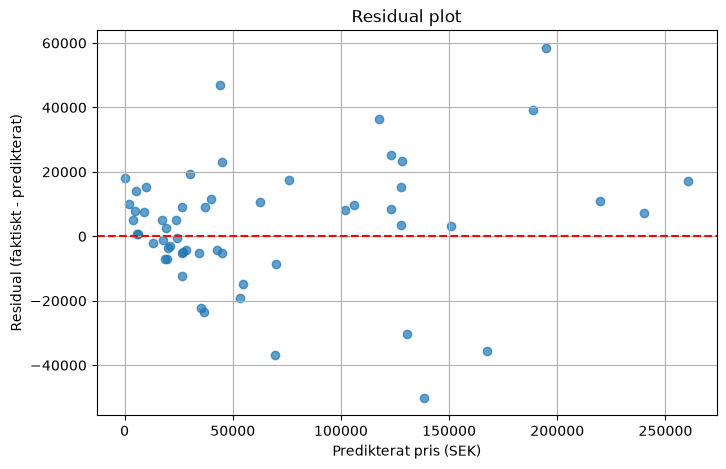

In [200]:
residuals = y_val - lin_reg_pred

plt.figure(figsize=(8, 5))

plt.scatter(lin_reg_pred, residuals, alpha=0.7)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predikterat pris (SEK)")
plt.ylabel("Residual (faktiskt - predikterat)")
plt.title("Residual plot")
plt.grid(True)

plt.show()


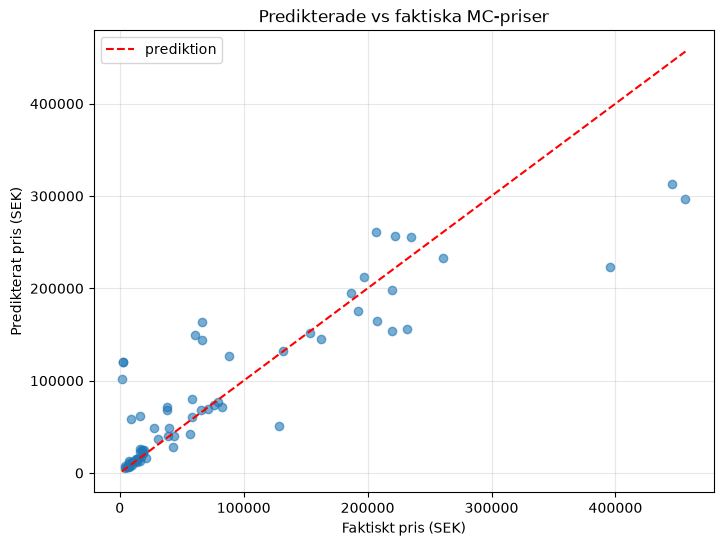

In [201]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Linje för perfekta prediktioner
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    color="red",
    linestyle="--",
    label="prediktion"
)

plt.xlabel("Faktiskt pris (SEK)")
plt.ylabel("Predikterat pris (SEK)")
plt.title("Predikterade vs faktiska MC-priser")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


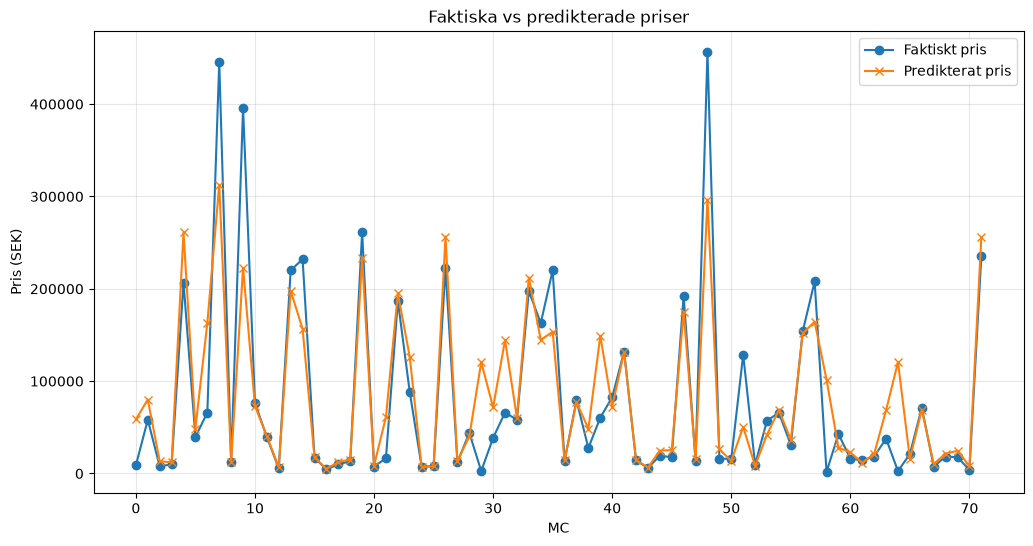

In [202]:
plt.figure(figsize=(12, 6))

plt.plot(y_test.values, label="Faktiskt pris", marker="o")
plt.plot(y_pred, label="Predikterat pris", marker="x")

plt.xlabel("MC")
plt.ylabel("Pris (SEK)")
plt.title("Faktiska vs predikterade priser")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


## The best model was linear regression so now we train it on the full dataset and save it.

In [203]:
lin_final_test = lin_reg.fit(x_train_val, y_train_val)
lin_reg_last = lin_final_test.predict(x_test)

print("RMSE: ", root_mean_squared_error(lin_reg_last, y_test))


RMSE:  30806.1606996164


In [182]:
# training on complete dataset. 
lr_finished = lin_reg.fit(x,y)

In [183]:
# joblib.dump(lr_finished, "Valuation_model.joblib")
# print("model saved")